### 1. Heatmap: Correlation between Runs, Balls, SR, Fours, Sixes

DataFrame Columns: Index(['Match_ID', 'Match_Date', 'Venue', 'Match_Format', 'Batsman',
       'Opponent', 'Runs_Scored', 'Balls_Faced', 'Strike_Rate',
       'Wickets_Taken', 'Overs_Bowled', 'Runs_Conceded', 'Match_Won', 'Year',
       'Month', 'Batting_StrikeRate', 'Bowling_Economy', 'Perf_Score'],
      dtype='object')


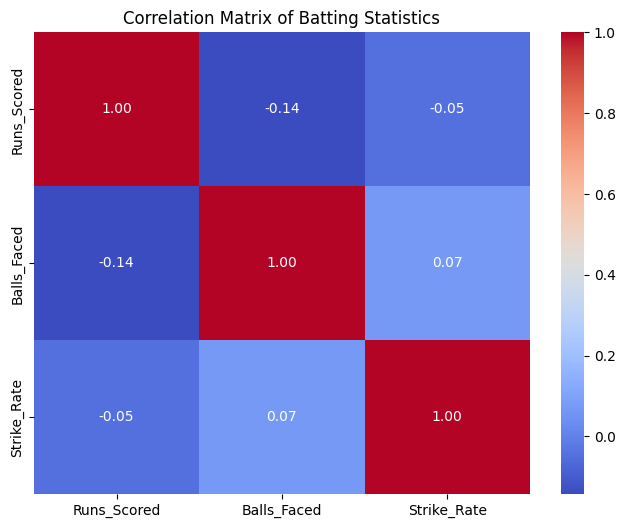

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the DataFrame first
# Assuming the CSV file is named 'cricket_cleaned.csv' and is in the /content/ directory
df = pd.read_csv('/content/cricket_cleaned.csv')

# Print columns to debug KeyError
print("DataFrame Columns:", df.columns)

# Correcting column names based on actual DataFrame columns
correlation_cols = ['Runs_Scored', 'Balls_Faced', 'Strike_Rate'] # Removed 'Fours' and 'Sixes' as they are not in df.columns
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Batting Statistics')
plt.show()

### 2. Boxplot: Runs Scored vs Match Format

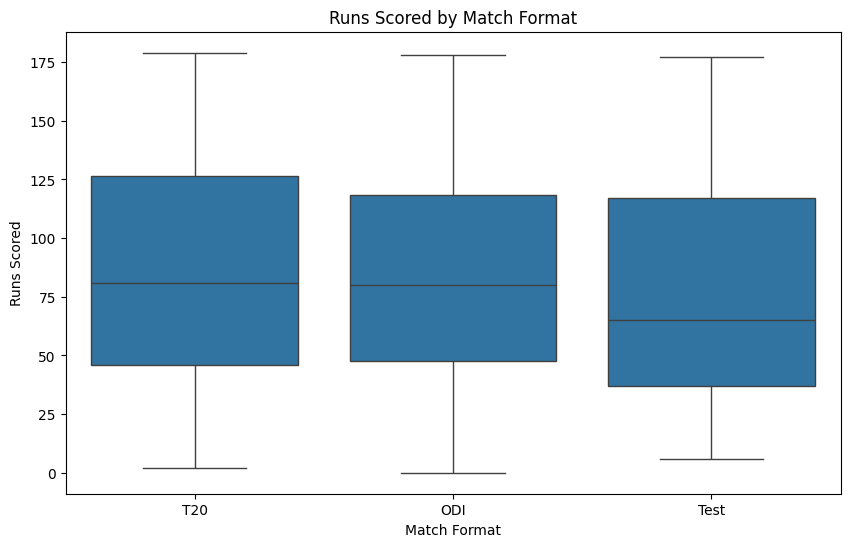

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Match_Format', y='Runs_Scored', data=df) # Corrected 'Match Format' to 'Match_Format' and 'Runs' to 'Runs_Scored'
plt.title('Runs Scored by Match Format')
plt.xlabel('Match Format')
plt.ylabel('Runs Scored')
plt.show()

### 3. Countplot: Player Role

/tmp/ipykernel_6354/2272593561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Player Role', data=df, palette='viridis')


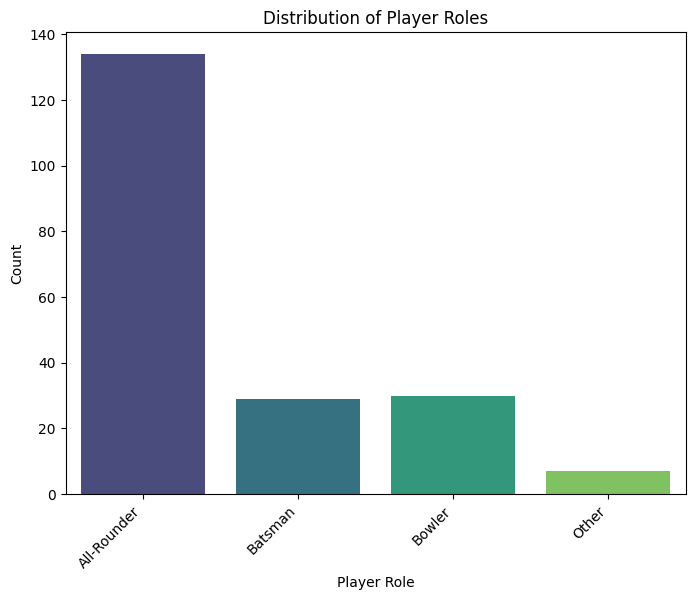

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Player Role', data=df, palette='viridis')
plt.title('Distribution of Player Roles')
plt.xlabel('Player Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [9]:
print(df.columns)

Index(['Match_ID', 'Match_Date', 'Venue', 'Match_Format', 'Batsman',
       'Opponent', 'Runs_Scored', 'Balls_Faced', 'Strike_Rate',
       'Wickets_Taken', 'Overs_Bowled', 'Runs_Conceded', 'Match_Won', 'Year',
       'Month', 'Batting_StrikeRate', 'Bowling_Economy', 'Perf_Score'],
      dtype='object')


### 4. Violin plot: Strike Rate by Venue

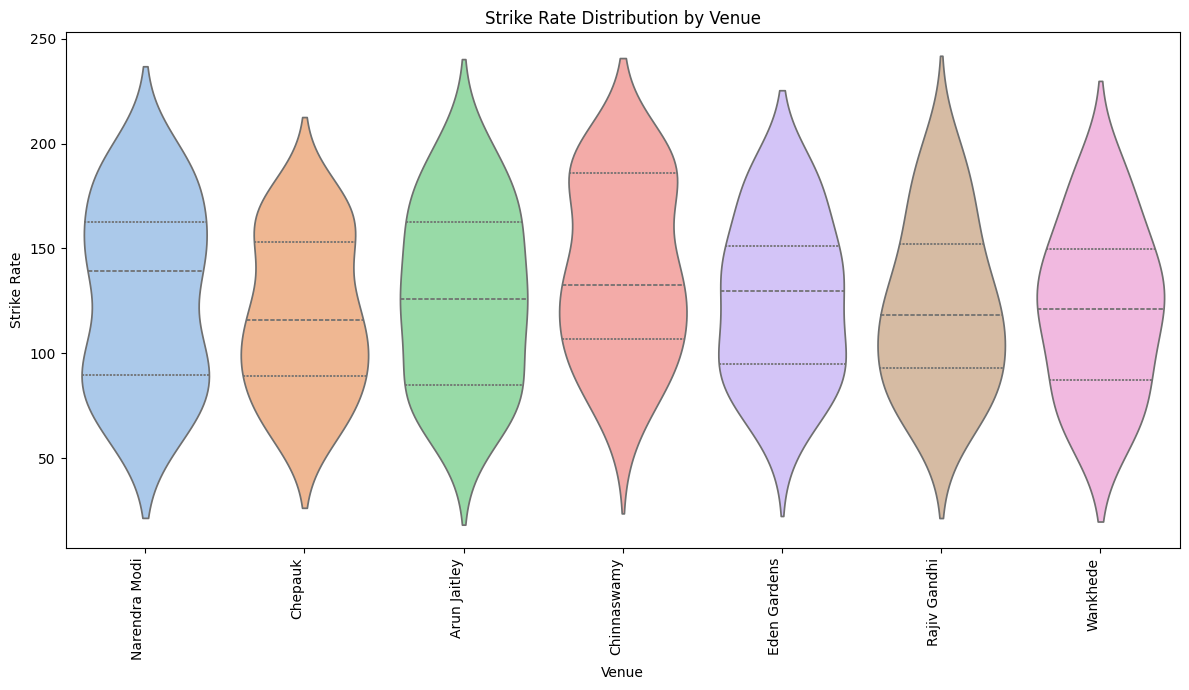

In [15]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='Venue', y='Strike_Rate', data=df, inner='quartile', palette='pastel', hue='Venue', legend=False)
plt.title('Strike Rate Distribution by Venue')
plt.xlabel('Venue')
plt.ylabel('Strike Rate')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### 5. Scatterplot: Runs vs Overs Bowled (All-rounders)

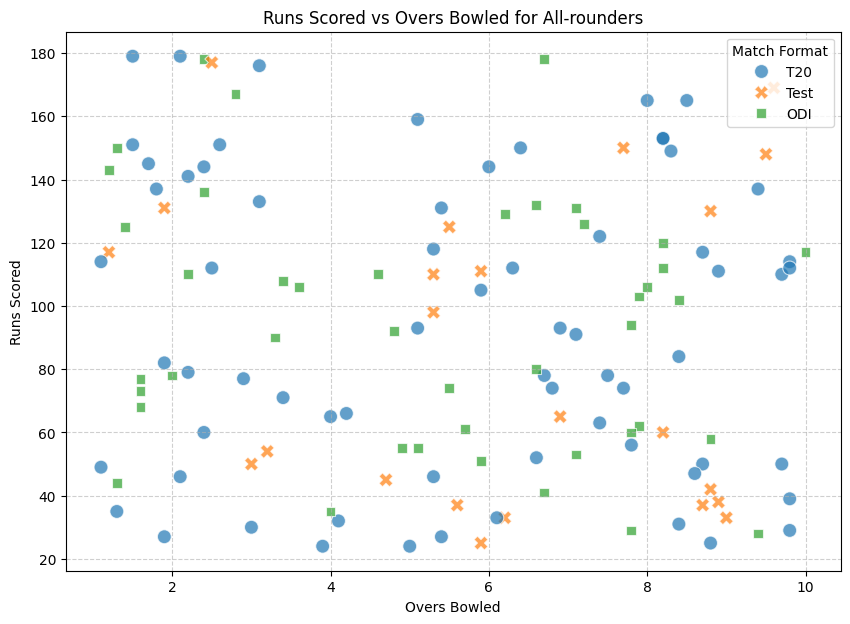

In [17]:
# Filter for all-rounders (assuming 'Player Role' contains 'All-Rounder' or similar)
all_rounders_df = df[df['Player Role'].str.contains('All-Rounder|Bowling Allrounder|Batting Allrounder', na=False, case=False)]

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Overs_Bowled', y='Runs_Scored', data=all_rounders_df, hue='Match_Format', style='Match_Format', s=100, alpha=0.7)
plt.title('Runs Scored vs Overs Bowled for All-rounders')
plt.xlabel('Overs Bowled')
plt.ylabel('Runs Scored')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Match Format')
plt.show()

In [13]:
# Function to assign player roles based on runs and wickets in a match
def assign_player_role(row):
    runs_threshold = 20  # You can adjust this threshold
    wickets_threshold = 1 # You can adjust this threshold

    is_batsman = row['Runs_Scored'] > runs_threshold
    is_bowler = row['Wickets_Taken'] >= wickets_threshold

    if is_batsman and is_bowler:
        return 'All-Rounder'
    elif is_batsman:
        return 'Batsman'
    elif is_bowler:
        return 'Bowler'
    else:
        return 'Other'

# Apply the function to create the 'Player Role' column
df['Player Role'] = df.apply(assign_player_role, axis=1)

print("First 5 rows with new 'Player Role' column:")
display(df[['Batsman', 'Runs_Scored', 'Wickets_Taken', 'Player Role']].head())

First 5 rows with new 'Player Role' column:


,Batsman,Runs_Scored,Wickets_Taken,Player Role
0,Hardik Pandya,50.0,4,All-Rounder
1,MS Dhoni,172.0,0,Batsman
2,MS Dhoni,3.0,4,Bowler
3,Virat Kohli,112.0,5,All-Rounder
4,Shubman Gill,31.0,5,All-Rounder


### 6. Barplot: Average Runs per Team

/tmp/ipykernel_6354/3877579315.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Batsman', y='Runs_Scored', data=avg_runs_per_player, palette='rocket')


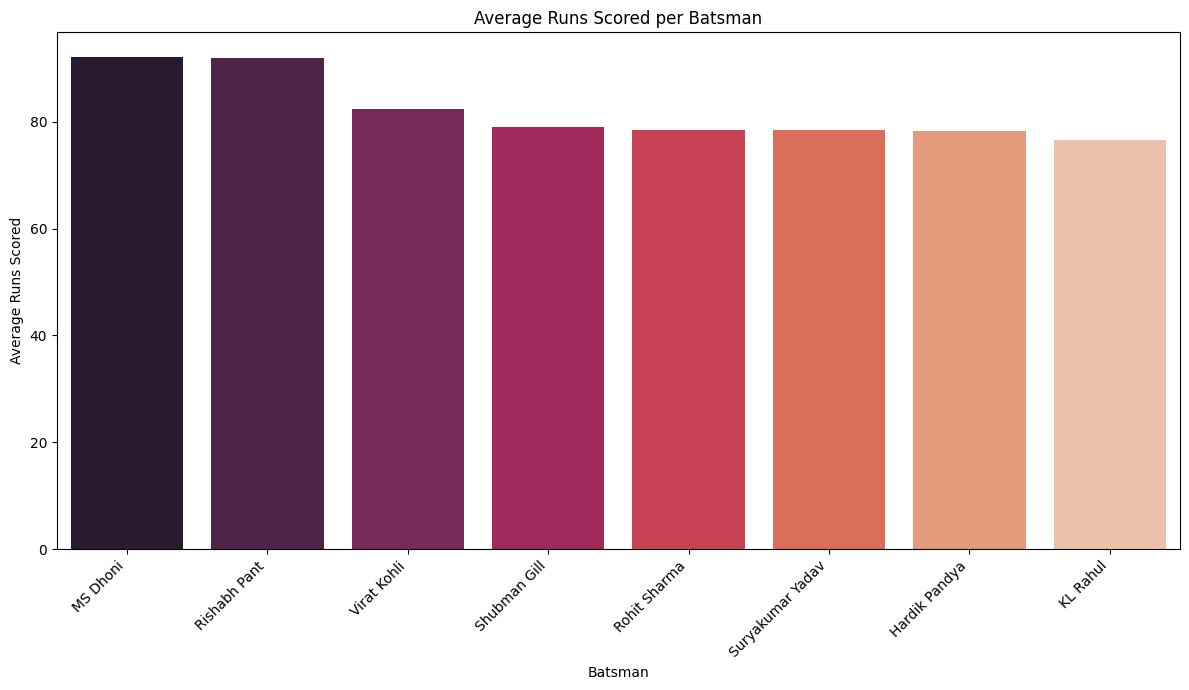

In [20]:
avg_runs_per_player = df.groupby('Batsman')['Runs_Scored'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Batsman', y='Runs_Scored', data=avg_runs_per_player, palette='rocket')
plt.title('Average Runs Scored per Batsman')
plt.xlabel('Batsman')
plt.ylabel('Average Runs Scored')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
excel_filename = 'cricket_data.xlsx'
df.to_excel(excel_filename, index=False)
print(f"DataFrame successfully saved to {excel_filename}")

DataFrame successfully saved to cricket_data.xlsx
